# SpaceX Falcon 9 First-Stage Landing Prediction

**Machine Learning Classification**  
IBM Applied Data Science Capstone  
Repository owner: `phuonganhdt220391`

## Objective

Build and compare four classifiers - logistic regression, support vector
machine, decision tree and k-nearest neighbors - to predict whether the
Falcon 9 first stage lands successfully.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = Path(".")
data = pd.read_csv(DATA_DIR / "dataset_part_2.csv")
X = pd.read_csv(DATA_DIR / "dataset_part_3.csv")
Y = data["Class"].to_numpy()

print("X shape:", X.shape)
print("Y distribution:", dict(zip(*np.unique(Y, return_counts=True))))
X.head()

X shape: (90, 80)
Y distribution: {np.int64(0): np.int64(30), np.int64(1): np.int64(60)}


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Standardize and split the data

The course exercise standardizes the feature matrix and uses a 20% test
split. Stratification preserves the class balance in both partitions.

In [2]:
transform = preprocessing.StandardScaler()
X_scaled = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.20, random_state=2, stratify=Y
)
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 72
Test rows: 18


In [3]:
model_specs = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=2),
        {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear"]},
    ),
    "Support Vector Machine": (
        SVC(random_state=2),
        {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"], "gamma": ["scale", "auto"]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=2),
        {"criterion": ["gini", "entropy"], "max_depth": [2, 4, 6, None],
         "min_samples_split": [2, 5]},
    ),
    "K-Nearest Neighbors": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 9], "weights": ["uniform", "distance"],
         "p": [1, 2]},
    ),
}

fitted_models = {}
rows = []
for name, (estimator, parameters) in model_specs.items():
    search = GridSearchCV(estimator, parameters, cv=5, scoring="accuracy", n_jobs=-1)
    search.fit(X_train, Y_train)
    prediction = search.predict(X_test)
    fitted_models[name] = search.best_estimator_
    rows.append({
        "Model": name,
        "CV Accuracy": search.best_score_,
        "Test Accuracy": accuracy_score(Y_test, prediction),
        "Best Parameters": search.best_params_,
    })

results = pd.DataFrame(rows).sort_values(
    ["Test Accuracy", "CV Accuracy"], ascending=False
).reset_index(drop=True)
results

,Model,CV Accuracy,Test Accuracy,Best Parameters
0,Decision Tree,0.862857,0.777778,"{'criterion': 'gini', 'max_depth': 2, 'min_sam..."
1,Logistic Regression,0.848571,0.777778,"{'C': 10, 'solver': 'liblinear'}"
2,K-Nearest Neighbors,0.835238,0.777778,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}"
3,Support Vector Machine,0.834286,0.666667,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"


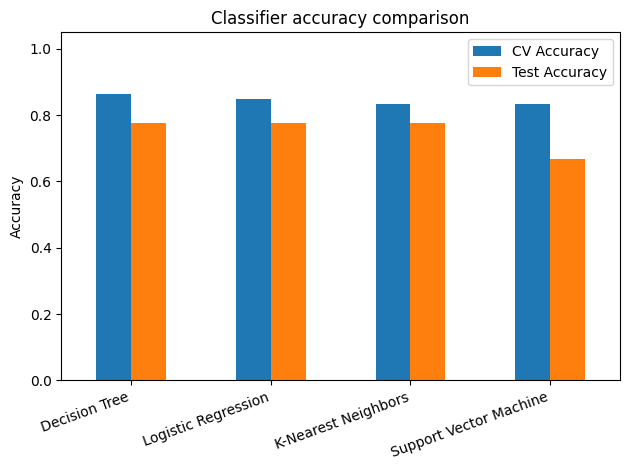

In [4]:
ax = results.set_index("Model")[["CV Accuracy", "Test Accuracy"]].plot(
    kind="bar", ylim=(0, 1.05), title="Classifier accuracy comparison"
)
ax.set_ylabel("Accuracy")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Best model: Decision Tree
Best parameters: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2}
Test accuracy: 0.778


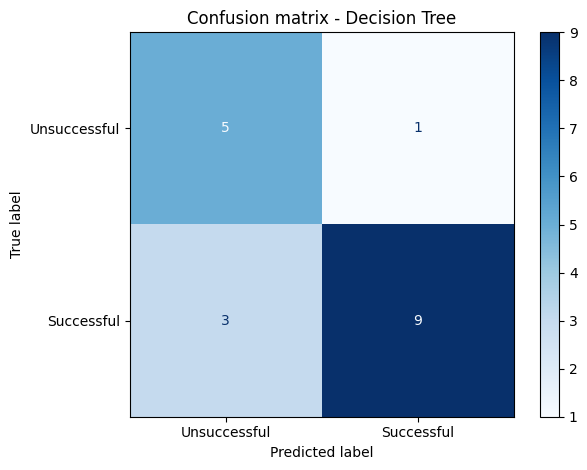

In [5]:
best_name = results.loc[0, "Model"]
best_model = fitted_models[best_name]
best_prediction = best_model.predict(X_test)

print("Best model:", best_name)
print("Best parameters:", results.loc[0, "Best Parameters"])
print(f"Test accuracy: {accuracy_score(Y_test, best_prediction):.3f}")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(Y_test, best_prediction),
    display_labels=["Unsuccessful", "Successful"],
).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

## Conclusion

The notebook compares all four classifiers with cross-validated parameter
tuning and reports the best model on the held-out test set. Because the
dataset is small, accuracy can vary with the split; the saved random seed
keeps the result reproducible.